In [1]:
from pathlib import Path
import json
from natsort import natsorted
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markerlist = ["o", "s", "D"]

mpl.rcParams["font.size"] = 14

BASERESULTSDIR = Path("out/")

# TODO: Both pbcFFF and pbcTTT?
dirstolabels_dr = {
    "pbc-FFF__defaultgrad__energy": "$U^{1+}$",
    "pbc-FFF__defaultgrad__dr": "default autodiff",
    "pbc-FFF__customjvp__dr": "opt. derivative",
}
dirstolabels_dq = {
    "pbc-FFF__defaultgrad__energy": "",
    "pbc-FFF__defaultgrad__dq": "",
    "pbc-FFF__customjvp__dq": "",
}
dirstolabels_energy_and_dr_and_dq = {
    "pbc-FFF__defaultgrad__energy": "",
    "pbc-FFF__defaultgrad__energy_and_dr_and_dq": "",
    "pbc-FFF__customjvp__energy_and_dr_and_dq": "",
}

quantity_title_dr = r"$\nabla_i U^{1+}$"
quantity_title_dq = r"$\frac{\partial U^{1+}}{\partial q_i}$"
quantity_title_energy_and_dr_and_dq = r"$\left(U^{1+}, \, \nabla_i U^{1+}, \, \frac{\partial U^{1+}}{\partial q_i}\right)$"

In [60]:
pbc_labels = ["pbc-FFF", "pbc-TTT"]
custom_deriv_labels = ["defaultgrad", "customjvp"]
quantities_to_titles = {
    "dr": r"$\nabla_i U^{1+}$",
    "dq": r"$\frac{\partial U^{1+}}{\partial q_i}$",
    "energy_and_dr_and_dq": r"$\left(U^{1+}, \, \nabla_i U^{1+}, \, \frac{\partial U^{1+}}{\partial q_i}\right)$",
}

# TODO: name
labels = ["$U^{1+}$", "default autodiff", "opt. derivative"]

In [44]:
# BASERESULTSDIR = Path("out_bak/")
#
# LBL_PBC = pbc_labels[0]
#
# dirname_energy = LBL_PBC + "__" + "energy"
# resultsdir_energy = BASERESULTSDIR / dirname_energy
# print(resultsdir_energy, resultsdir_energy.is_dir())
# print()
#
# for lbl_quantity in quantities_to_titles:
#     for lbl_custom_deriv in custom_deriv_labels:
#         dirname_deriv = "__".join([LBL_PBC, lbl_custom_deriv, lbl_quantity])
#         dir_deriv = BASERESULTSDIR / dirname_deriv
#         print(dir_deriv, dir_deriv.is_dir())
#     print()

out_bak/pbc-FFF__energy True

out_bak/pbc-FFF__defaultgrad__dr True
out_bak/pbc-FFF__customjvp__dr True

out_bak/pbc-FFF__defaultgrad__dq True
out_bak/pbc-FFF__customjvp__dq True

out_bak/pbc-FFF__defaultgrad__energy_and_dr_and_dq True
out_bak/pbc-FFF__customjvp__energy_and_dr_and_dq True



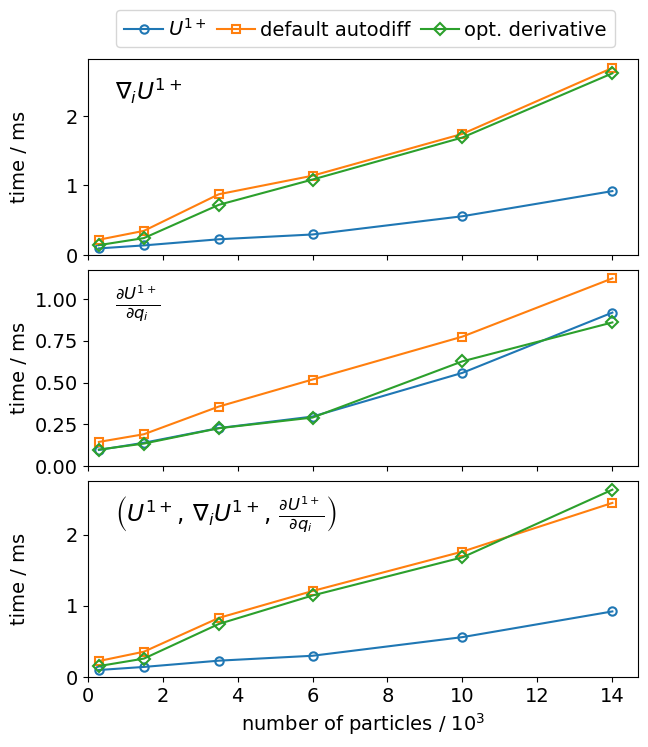

In [64]:
BASERESULTSDIR = Path("out_bak/")

LBL_PBC = pbc_labels[0]

filename_without_suffix = "timing_default_vs_custom_grad" + "__" + LBL_PBC

fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    figsize=(6.4, 7.4),
)
axs[-1].set_xlabel("number of particles / $10^3$")

dirname_energy = LBL_PBC + "__" + "energy"
resultsdir_energy = BASERESULTSDIR / dirname_energy

for i, ((quantity, quantity_label), ax) in enumerate(
    zip(quantities_to_titles.items(), axs)
):
    ax.set_title(quantity_label, x=0.05, y=0.75, ha="left")
    ax.set_ylabel("time / ms")

    dirnames_deriv = [
        "__".join([LBL_PBC, lbl_custom_deriv, quantity])
        for lbl_custom_deriv in custom_deriv_labels
    ]
    dirnames_combined = [dirname_energy] + dirnames_deriv

    for dirname, deriv_label, color, marker in zip(
        dirnames_combined, labels, default_colors, markerlist
    ):
        resultsdir = BASERESULTSDIR / dirname
        nbs_particles = onp.loadtxt(
            resultsdir / "times_vs_n_particles.txt", usecols=0, dtype=int
        )
        times = onp.loadtxt(
            resultsdir / "times_vs_n_particles.txt", usecols=1, dtype=float
        )
        ax.plot(
            nbs_particles / 1000,
            times * 1000,
            label=deriv_label,
            marker=marker,
            color=color,
            markerfacecolor="none",
            markeredgewidth=1.5,
        )

    ax.set_xlim(0, ax.get_xlim()[1])
    ax.set_ylim(0, ax.get_ylim()[1])

plt.subplots_adjust(
    left=0.13, right=0.99, bottom=0.09, top=0.925, hspace=0.075
)
fig.align_ylabels()
axs[0].legend(
    ncols=3,
    handletextpad=0.25,
    columnspacing=0.5,
    bbox_to_anchor=(0.975, 1.3),
    bbox_transform=axs[0].transAxes,
)

for suffix in ["png", "pdf"]:
    filename_plot = filename_without_suffix + "." + suffix
    fig.savefig(BASERESULTSDIR / (filename_plot))

plt.show()

FileNotFoundError: out/pbc-FFF__defaultgrad__energy/times_vs_n_particles.txt not found.

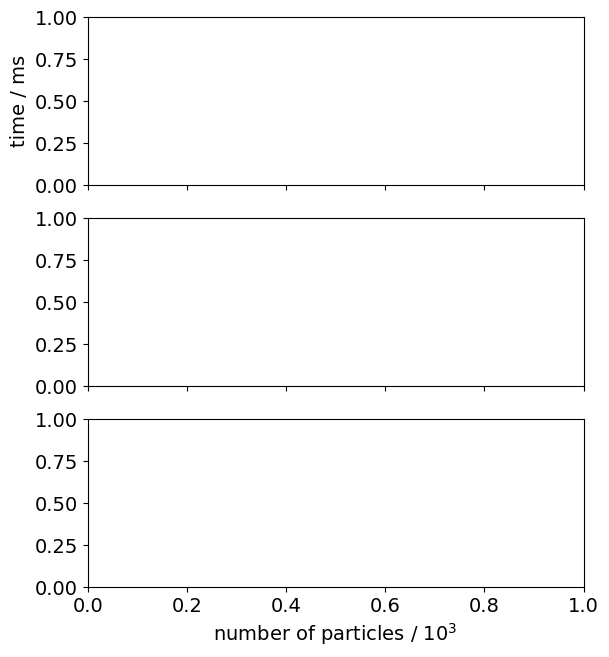

In [4]:
# filename_without_suffix = "timing_default_vs_custom_grad"
#
# fig, axs = plt.subplots(
#     nrows=3,
#     ncols=1,
#     sharex=True,
#     figsize=(6.4, 7.4),
# )
# axs[-1].set_xlabel("number of particles / $10^3$")
#
# for mapping, quantity, ax in zip(
#     [dirstolabels_dr, dirstolabels_dq, dirstolabels_energy_and_dr_and_dq],
#     [
#         quantity_title_dr,
#         quantity_title_dq,
#         quantity_title_energy_and_dr_and_dq,
#     ],
#     axs,
# ):
#     ax.set_ylabel("time / ms")
#
#     for (dirname, label), color, marker in zip(
#         mapping.items(), default_colors, markerlist
#     ):
#         resultsdir = BASERESULTSDIR / dirname
#
#         nbs_particles = onp.loadtxt(
#             resultsdir / "times_vs_n_particles.txt", usecols=0, dtype=int
#         )
#         times = onp.loadtxt(
#             resultsdir / "times_vs_n_particles.txt", usecols=1, dtype=float
#         )
#         ax.plot(
#             nbs_particles / 1000,
#             times * 1000,
#             label=label,
#             marker=marker,
#             color=color,
#             markerfacecolor="none",
#             markeredgewidth=1.5,
#         )
#         ax.set_title(quantity, x=0.05, y=0.75, ha="left")
#
#     ax.set_xlim(0, ax.get_xlim()[1])
#     ax.set_ylim(0, ax.get_ylim()[1])
#
# plt.subplots_adjust(
#     left=0.13, right=0.99, bottom=0.09, top=0.925, hspace=0.075
# )
# fig.align_ylabels()
#
# axs[0].legend(
#     ncols=3,
#     handletextpad=0.25,
#     columnspacing=0.5,
#     bbox_to_anchor=(0.975, 1.3),
#     bbox_transform=axs[0].transAxes,
# )
#
# for suffix in ["png", "pdf"]:
#     filename_plot = filename_without_suffix + "." + suffix
#     fig.savefig(BASERESULTSDIR / (filename_plot))
#
# plt.show()